In [6]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# ==========================================
# STEP 1: Load and Clean Data
# ==========================================
df = pd.read_csv('flood_data.csv')

# Fix date format for Philippines/Standard (Day/Month/Year)
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# Sort by location and time to ensure sequence integrity
df = df.sort_values(['Barangay', 'Date'])

In [7]:
# STEP 2: Feature Engineering & Target Setting
# ==========================================
# Extract seasonal time features
df['Month'] = df['Date'].dt.month
df['Day_of_Year'] = df['Date'].dt.dayofyear

# Encode Barangay names to numeric IDs
le = LabelEncoder()
df['Barangay_ID'] = le.fit_transform(df['Barangay'])

# DEFINE THE TARGET: Predict if a flood happens TOMORROW
# First, define what a flood condition is
df['Is_Flood'] = (df['Rain_3Day_Sum'] > 150).astype(int)

# Shift it so today's features predict tomorrow's flood status
df['Target_Tomorrow'] = df.groupby('Barangay')['Is_Flood'].shift(-1)

# Drop rows where we don't have a "tomorrow" to compare against
df = df.dropna(subset=['Target_Tomorrow'])

In [8]:
# STEP 3: Data Splitting
# ==========================================
# We remove 'Rain_3Day_Sum' and 'Is_Flood' from features to prevent leakage.
# The model must learn from raw rain, location, and time.
features = ['Rainfall_mm', 'Static_Score', 'Month', 'Day_of_Year', 'Barangay_ID']
X = df[features]
y = df['Target_Tomorrow']

# Split chronologically (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [9]:
# STEP 4: XGBoost Model Training
# ==========================================
model = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    scale_pos_weight=5, # Weights flood events higher since they are rare
    eval_metric='logloss',
    random_state=42
)

# Monitor training to prevent overfitting
model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False
)

print("--- Model Training Complete ---")

--- Model Training Complete ---


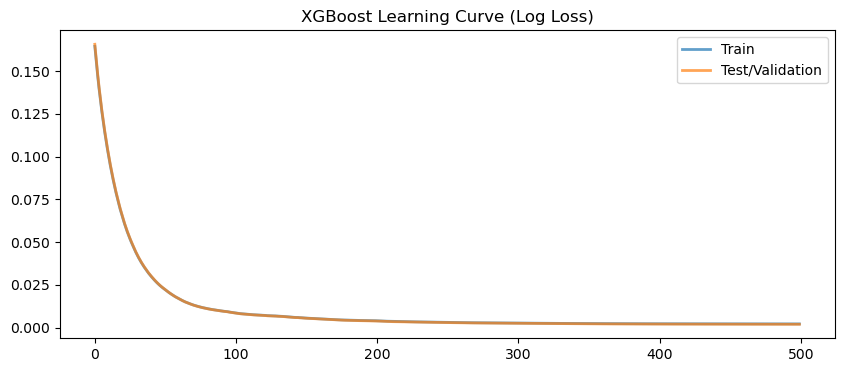

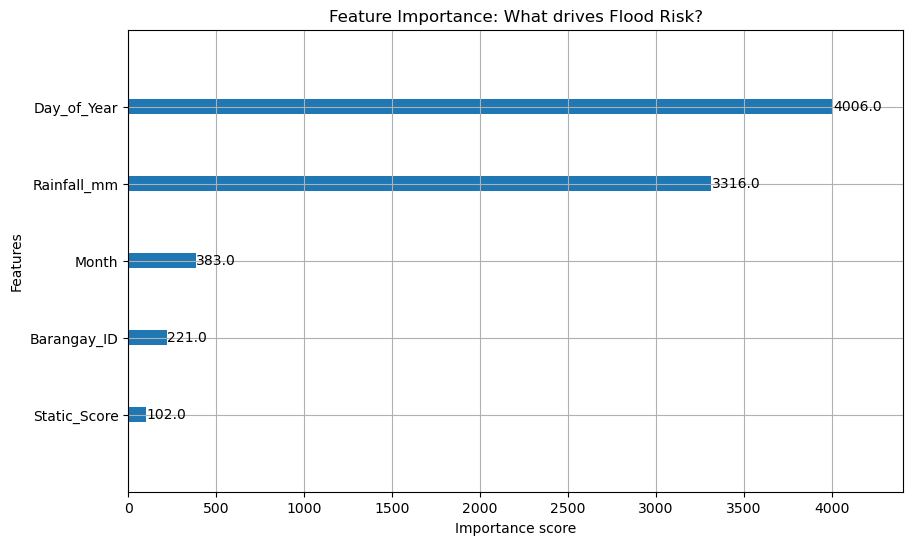

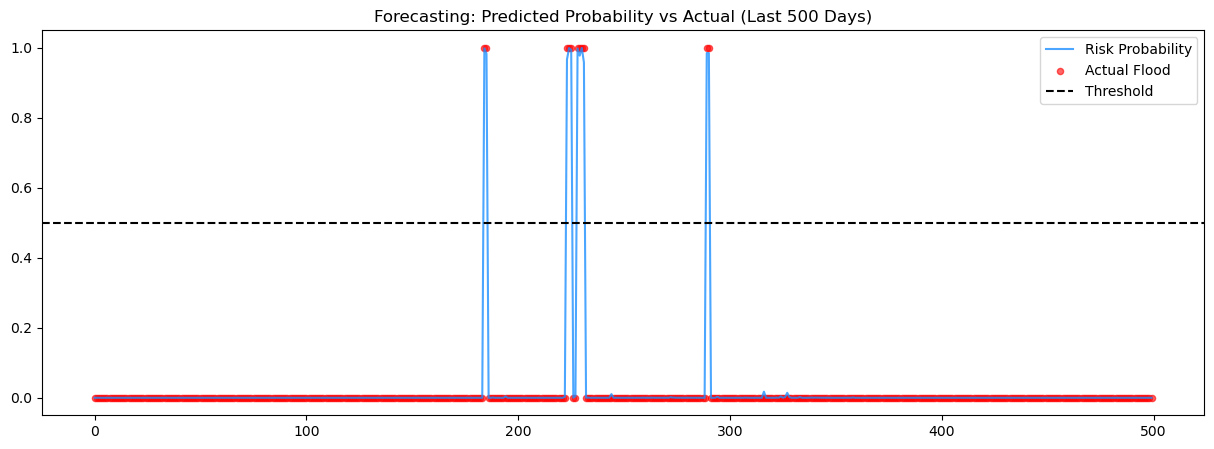

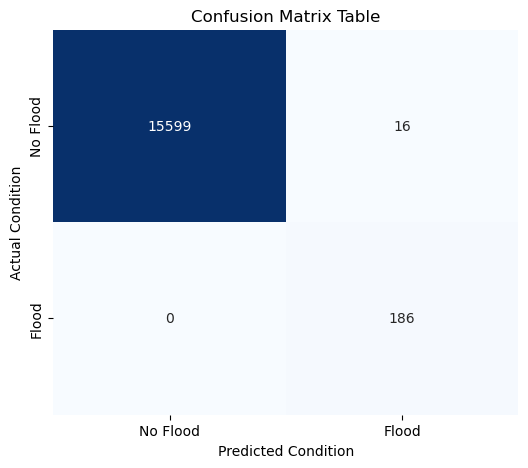

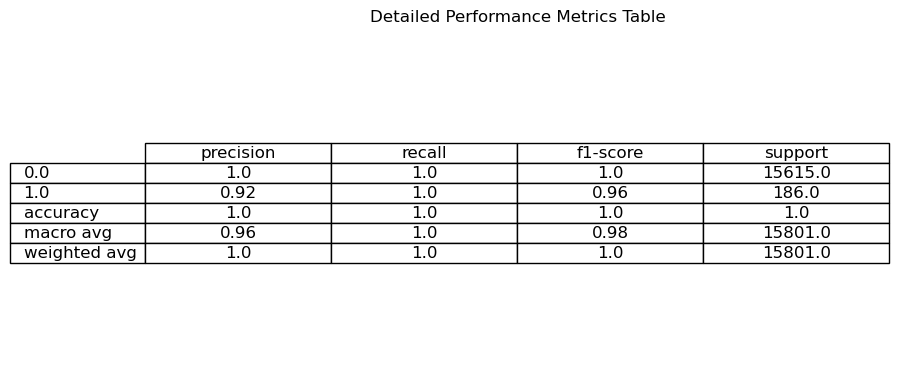

In [10]:
import seaborn as sns # Seaborn makes heatmaps look much better

# ==========================================
# STEP 5: Visualizations & Evaluation
# ==========================================
predictions = model.predict(X_test)

# 1. Learning Curve
results = model.evals_result()
plt.figure(figsize=(10, 4))
plt.plot(results['validation_0']['logloss'], label='Train', linewidth=2, alpha=0.7)
plt.plot(results['validation_1']['logloss'], label='Test/Validation', linewidth=2, alpha=0.7)
plt.title('XGBoost Learning Curve (Log Loss)')
plt.legend()
plt.show()

# 2. Feature Importance
plt.figure(figsize=(10, 6))
xgb.plot_importance(model, ax=plt.gca(), importance_type='weight')
plt.title('Feature Importance: What drives Flood Risk?')
plt.show()

# 3. Prediction Probability Graph (Zoomed for clarity)
y_probs = model.predict_proba(X_test)[:, 1]
plt.figure(figsize=(15, 5))
# Show the last 500 days so it's readable
window = 500 
plt.plot(range(window), y_probs[-window:], color='dodgerblue', label='Risk Probability', alpha=0.8)
plt.scatter(range(window), y_test.values[-window:], color='red', s=20, label='Actual Flood', alpha=0.6)
plt.axhline(y=0.5, color='black', linestyle='--', label='Threshold')
plt.title(f'Forecasting: Predicted Probability vs Actual (Last {window} Days)')
plt.legend()
plt.show()

# 4. VISUAL TABLE: Confusion Matrix Heatmap
cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Flood', 'Flood'], 
            yticklabels=['No Flood', 'Flood'])
plt.title('Confusion Matrix Table')
plt.ylabel('Actual Condition')
plt.xlabel('Predicted Condition')
plt.show()

# 5. VISUAL TABLE: Classification Report
# This converts the text report into a visual dataframe/table
report = classification_report(y_test, predictions, output_dict=True)
report_df = pd.DataFrame(report).transpose()

fig, ax = plt.subplots(figsize=(8, 4))
ax.axis('off')
tbl = ax.table(cellText=report_df.values.round(2), 
               colLabels=report_df.columns, 
               rowLabels=report_df.index, 
               loc='center', 
               cellLoc='center')
tbl.set_fontsize(12)
tbl.scale(1.2, 1.2)
plt.title('Detailed Performance Metrics Table', pad=20)
plt.show()